U4_S14: Tarea: Análisis Discriminante (LDA y QDA)

> Estudiante: Romina Salomé Vera Narváez



# U4_S14: Análisis Discriminante Lineal (LDA) y Cuadrático (QDA)

**Dataset utilizado:** Wine Dataset de `sklearn.datasets.load_wine`  
**Condición de la tarea:** usar el Wine Dataset **sin tratamiento**.

## Índice del notebook

1. Descripción del conjunto de datos  
2. Exploración de los datos  
3. Visualización  
4. Preparación de los datos  
5. Implementación de LDA  
6. Implementación de QDA  
7. Comparación de modelos  
8. Fronteras de decisión  
9. Conclusiones  


## Importación de librerías


In [5]:
# Librerías base para manejo de datos
import numpy as np
import pandas as pd

# Librerías para visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías de scikit-learn
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Utilidades
from IPython.display import display
from time import perf_counter
from matplotlib.colors import ListedColormap

# Configuración general
RANDOM_STATE = 42
TEST_SIZE = 0.25

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
np.set_printoptions(precision=4, suppress=True)

print("Librerías importadas correctamente.")


Librerías importadas correctamente.


## 1. Descripción del conjunto de datos

In [6]:
# Carga del Wine Dataset desde scikit-learn
wine = load_wine(as_frame=True)

# Variables predictoras y variable objetivo
X = wine.data.copy()
y = wine.target.copy()

# DataFrame completo para exploración
df = X.copy()
df["target"] = y
df["target_name"] = df["target"].map(dict(enumerate(wine.target_names)))

df.to_csv("wine_dataset.csv", index=False)

print("Origen del dataset:")
print("Wine Recognition Dataset, disponible en scikit-learn mediante load_wine().")
print("El dataset contiene resultados de análisis químico de vinos de tres cultivares diferentes.\n")

print(f"Número de observaciones: {df.shape[0]}")
print(f"Número de variables predictoras: {X.shape[1]}")
print(f"Variable objetivo: target")
print(f"Cantidad de clases: {len(wine.target_names)}")
print(f"Nombres de clases: {list(wine.target_names)}")
print("\nPrimeras filas del dataset:")
display(df.head())


Origen del dataset:
Wine Recognition Dataset, disponible en scikit-learn mediante load_wine().
El dataset contiene resultados de análisis químico de vinos de tres cultivares diferentes.

Número de observaciones: 178
Número de variables predictoras: 13
Variable objetivo: target
Cantidad de clases: 3
Nombres de clases: [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]

Primeras filas del dataset:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,target_name
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0



**Interpretación:**  
El conjunto de datos corresponde a un problema de **clasificación multiclase**, porque la variable objetivo identifica a qué cultivar pertenece cada vino. Las variables predictoras son numéricas y representan medidas químicas como alcohol, magnesio, flavonoides, intensidad de color y prolina.


## 2. Exploración de los datos

In [7]:
# Dimensiones del dataset
print("Dimensiones del DataFrame completo:")
print(df.shape)

# Tipos de variables
print("\nTipos de variables:")
display(df.dtypes.to_frame("tipo"))

# Valores faltantes
print("\nValores faltantes por columna:")
display(df.isna().sum().to_frame("faltantes"))

# Estadísticas descriptivas de las variables numéricas
print("\nEstadísticas descriptivas:")
display(df.drop(columns=["target_name"]).describe().T)

# Distribución de la variable objetivo
print("\nDistribución de clases:")
display(df["target_name"].value_counts().to_frame("cantidad"))


Dimensiones del DataFrame completo:
(178, 15)

Tipos de variables:


,tipo
alcohol,float64
malic_acid,float64
ash,float64
alcalinity_of_ash,float64
magnesium,float64
total_phenols,float64
flavanoids,float64
nonflavanoid_phenols,float64
proanthocyanins,float64
color_intensity,float64



Valores faltantes por columna:


,faltantes
alcohol,0
malic_acid,0
ash,0
alcalinity_of_ash,0
magnesium,0
total_phenols,0
flavanoids,0
nonflavanoid_phenols,0
proanthocyanins,0
color_intensity,0



Estadísticas descriptivas:


,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00



Distribución de clases:


,cantidad
target_name,
class_1,71
class_0,59
class_2,48



**Interpretación:**  
El dataset no presenta valores faltantes, por lo que no es necesario aplicar imputación. Además, todas las variables predictoras son numéricas, lo que permite entrenar LDA y QDA directamente. Las clases no son perfectamente iguales, pero la diferencia no es extrema; por eso se usará partición estratificada y métricas macro.


### Revisión exploratoria de supuestos estadísticos para LDA y QDA

Esta parte complementa la exploración porque LDA y QDA se basan en medias y matrices de covarianza. No modifica el dataset; solo ayuda a interpretar los modelos.

In [8]:
# Tamaño de cada clase
print("Cantidad de observaciones por clase:")
display(df.groupby("target_name").size().to_frame("n"))

# Media por clase para observar diferencias entre grupos
print("\nMedias de variables por clase:")
display(df.groupby("target_name")[wine.feature_names].mean().round(2))

# Comparación simple de matrices de covarianza por clase
covariances = {}
for clase_id, clase_nombre in enumerate(wine.target_names):
    X_clase = df[df["target"] == clase_id][wine.feature_names]
    covariances[clase_nombre] = np.cov(X_clase, rowvar=False)

# Distancia de Frobenius entre matrices de covarianza
clases = list(wine.target_names)
dist_cov = pd.DataFrame(index=clases, columns=clases, dtype=float)

for i, c1 in enumerate(clases):
    for j, c2 in enumerate(clases):
        dist_cov.loc[c1, c2] = np.linalg.norm(covariances[c1] - covariances[c2], ord="fro")

print("\nDistancia de Frobenius entre matrices de covarianza por clase:")
display(dist_cov.round(2))

print("Interpretación:")
print("LDA asume una matriz de covarianza común para todas las clases.")
print("QDA permite que cada clase tenga su propia matriz de covarianza.")
print("Si las matrices son bastante diferentes, QDA puede adaptarse mejor; si son parecidas, LDA suele ser más estable.")


Cantidad de observaciones por clase:


,n
target_name,
class_0,59
class_1,71
class_2,48



Medias de variables por clase:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
target_name,,,,,,,,,,,,,
class_0,13.74,2.01,2.46,17.04,106.34,2.84,2.98,0.29,1.90,5.53,1.06,3.16,1115.71
class_1,12.28,1.93,2.24,20.24,94.55,2.26,2.08,0.36,1.63,3.09,1.06,2.79,519.51
class_2,13.15,3.33,2.44,21.42,99.31,1.68,0.78,0.45,1.15,7.40,0.68,1.68,629.90



Distancia de Frobenius entre matrices de covarianza por clase:


,class_0,class_1,class_2
class_0,0.00,24470.76,35834.33
class_1,24470.76,0.00,11570.24
class_2,35834.33,11570.24,0.00


Interpretación:
LDA asume una matriz de covarianza común para todas las clases.
QDA permite que cada clase tenga su propia matriz de covarianza.
Si las matrices son bastante diferentes, QDA puede adaptarse mejor; si son parecidas, LDA suele ser más estable.


## 3. Visualización

En esta sección se incluyen más de tres visualizaciones, distribución de clases, histogramas, boxplots, dispersión y mapa de correlaciones. Cada gráfico incluye una breve interpretación.

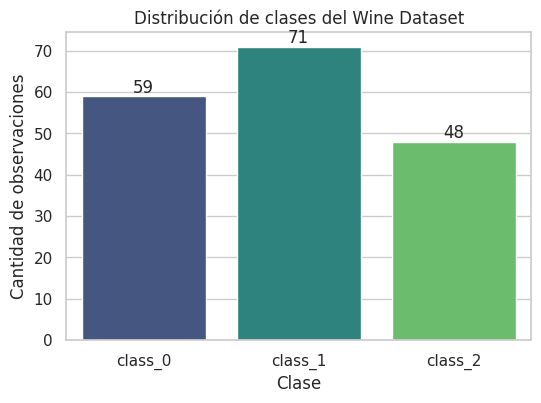

Interpretación:
La clase class_1 tiene más observaciones, seguida de class_0 y class_2.
Como las proporciones no son idénticas, se usa stratify=y en la separación train/test.


In [9]:
# Visualización 1: distribución de clases
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x="target_name", hue="target_name", palette="viridis", legend=False)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribución de clases del Wine Dataset")
plt.xlabel("Clase")
plt.ylabel("Cantidad de observaciones")
plt.show()

print("Interpretación:")
print("La clase class_1 tiene más observaciones, seguida de class_0 y class_2.")
print("Como las proporciones no son idénticas, se usa stratify=y en la separación train/test.")


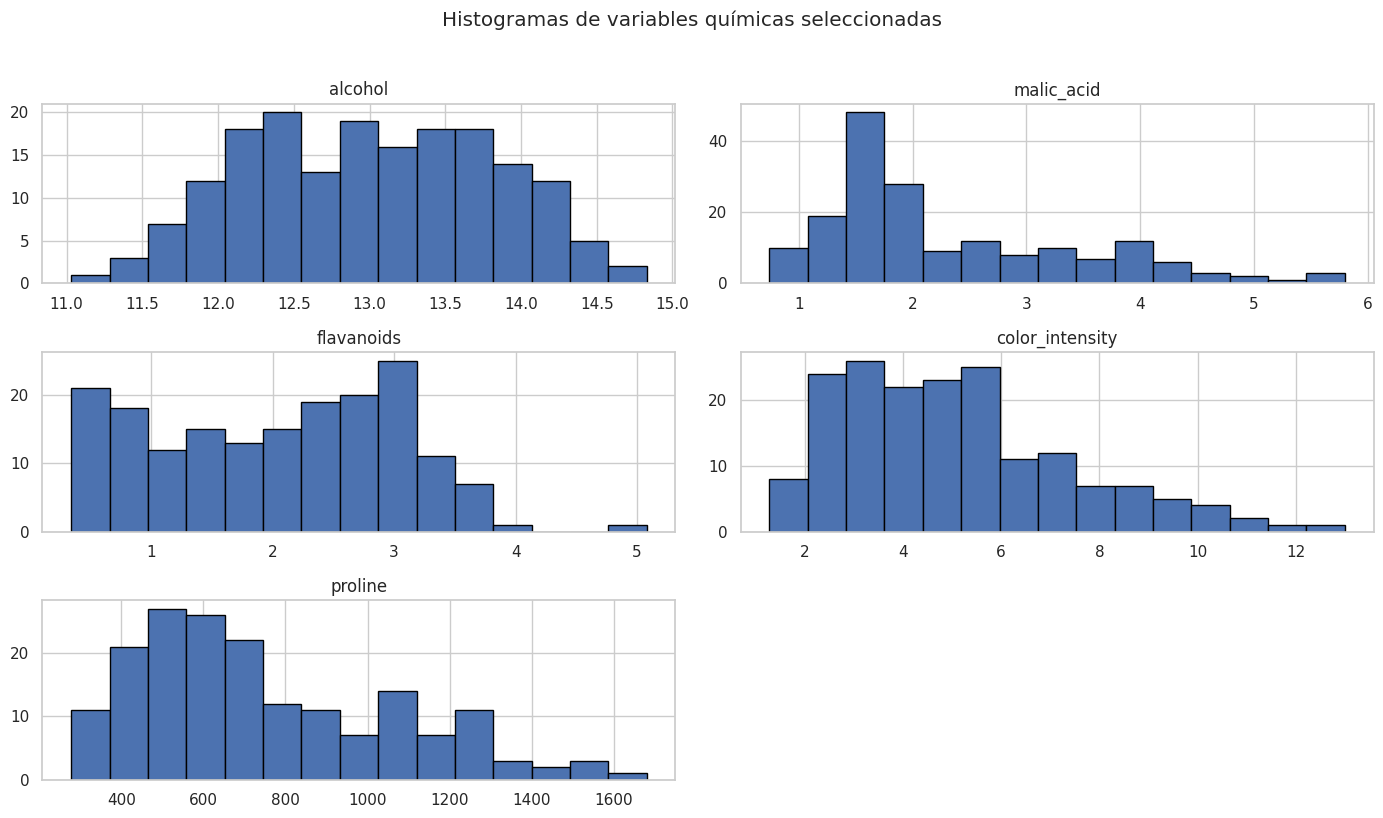

Interpretación:
Las variables presentan escalas y formas de distribución diferentes.
Por ejemplo, proline tiene valores mucho más grandes que alcohol o flavanoids.
Esto se documenta porque algunos modelos pueden ser sensibles a la escala, aunque aquí se conserva el dataset sin limpieza ni eliminación de datos.


In [10]:
# Visualización 2: histogramas de variables químicas seleccionadas
variables_hist = ["alcohol", "malic_acid", "flavanoids", "color_intensity", "proline"]

df[variables_hist].hist(figsize=(14, 8), bins=15, edgecolor="black")
plt.suptitle("Histogramas de variables químicas seleccionadas", y=1.02)
plt.tight_layout()
plt.show()

print("Interpretación:")
print("Las variables presentan escalas y formas de distribución diferentes.")
print("Por ejemplo, proline tiene valores mucho más grandes que alcohol o flavanoids.")
print("Esto se documenta porque algunos modelos pueden ser sensibles a la escala, aunque aquí se conserva el dataset sin limpieza ni eliminación de datos.")


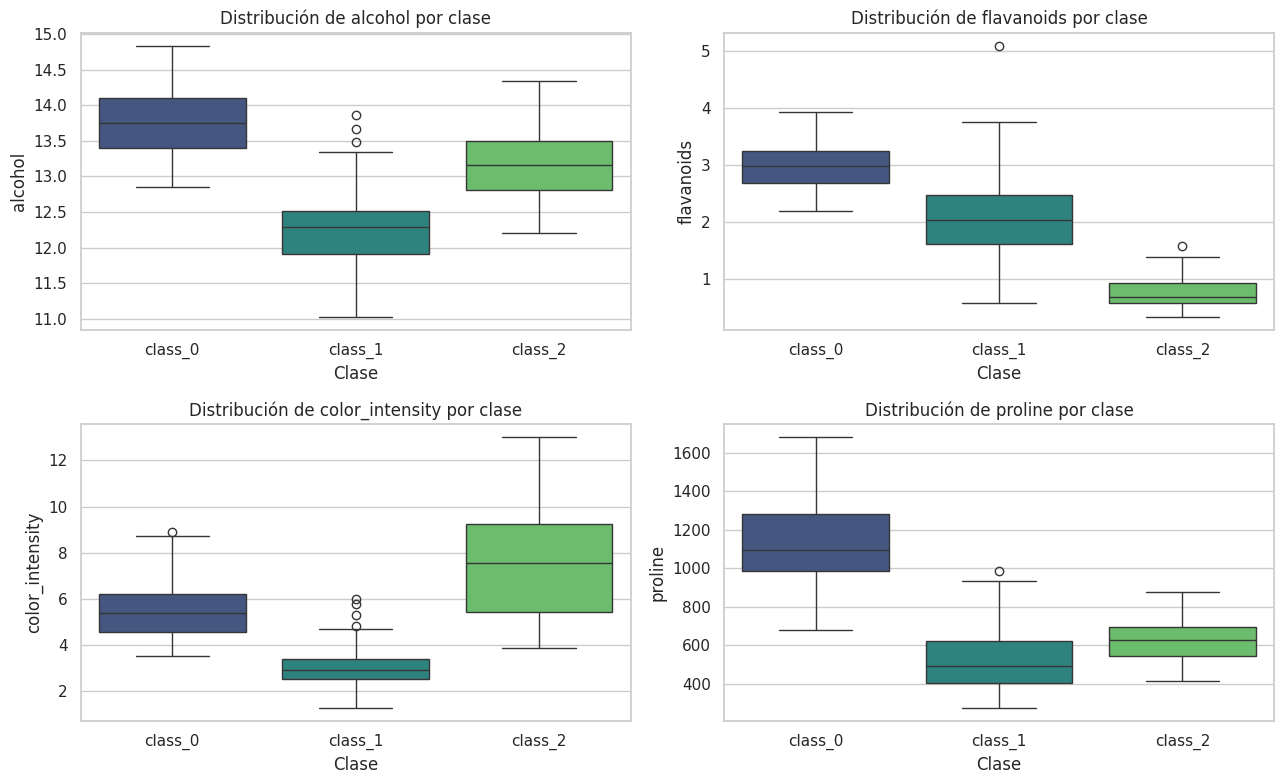

Interpretación:
Los boxplots muestran que algunas variables separan bastante bien las clases.
Por ejemplo, flavanoids y proline presentan diferencias visibles entre cultivares.
Esto anticipa que LDA y QDA pueden tener buen desempeño predictivo.


In [11]:
# Visualización 3: boxplots por clase
variables_box = ["alcohol", "flavanoids", "color_intensity", "proline"]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.ravel()

for ax, col in zip(axes, variables_box):
    sns.boxplot(data=df, x="target_name", y=col, hue="target_name", palette="viridis", legend=False, ax=ax)
    ax.set_title(f"Distribución de {col} por clase")
    ax.set_xlabel("Clase")
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

print("Interpretación:")
print("Los boxplots muestran que algunas variables separan bastante bien las clases.")
print("Por ejemplo, flavanoids y proline presentan diferencias visibles entre cultivares.")
print("Esto anticipa que LDA y QDA pueden tener buen desempeño predictivo.")


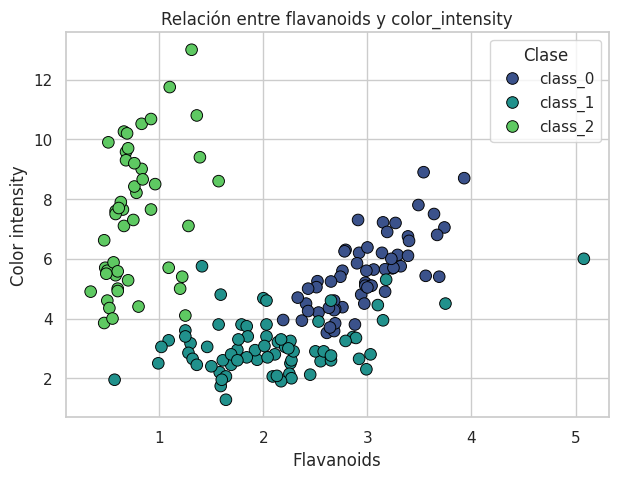

Interpretación:
Se observa una separación parcial entre las clases, pero también existen zonas de solapamiento.
Ese solapamiento justifica comparar una frontera lineal (LDA) con una frontera más flexible (QDA).


In [14]:
# Visualización 4: dispersión de dos variables representativas
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=df,
    x="flavanoids",
    y="color_intensity",
    hue="target_name",
    palette="viridis",
    s=70,
    edgecolor="black"
)
plt.title("Relación entre flavanoids y color_intensity")
plt.xlabel("Flavanoids")
plt.ylabel("Color intensity")
plt.legend(title="Clase")
plt.show()

print("Interpretación:")
print("Se observa una separación parcial entre las clases, pero también existen zonas de solapamiento.")
print("Ese solapamiento justifica comparar una frontera lineal (LDA) con una frontera más flexible (QDA).")


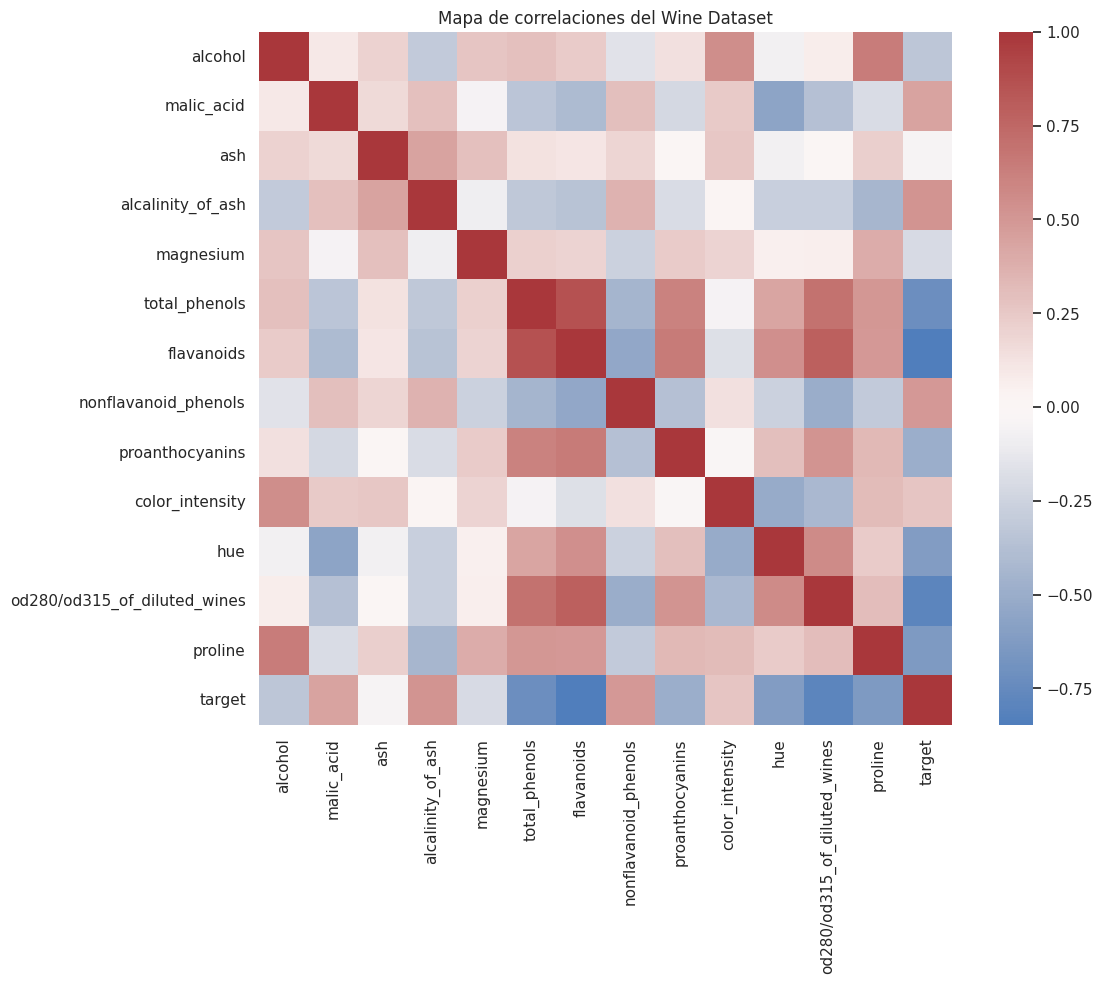

Interpretación:
Existen correlaciones importantes entre varias variables químicas.
Esto es relevante porque LDA y QDA se apoyan en medias y matrices de covarianza para separar las clases.


In [16]:
# Visualización 5: mapa de correlaciones
plt.figure(figsize=(12, 9))
corr = df.drop(columns=["target_name"]).corr(numeric_only=True)
sns.heatmap(corr, cmap="vlag", center=0, annot=False, square=True)
plt.title("Mapa de correlaciones del Wine Dataset")
plt.show()

print("Interpretación:")
print("Existen correlaciones importantes entre varias variables químicas.")
print("Esto es relevante porque LDA y QDA se apoyan en medias y matrices de covarianza para separar las clases.")


## 4. Preparación de los datos

En esta sección se separan los datos en entrenamiento y prueba. También se define la validación cruzada estratificada para evaluar los modelos de forma más estable.

**Importante:** como la tarea pide usar el Wine Dataset sin tratamiento, no se eliminan datos, no se imputan valores, no se eliminan valores atípicos y no se aplica estandarización al modelo principal.

In [18]:
# Separación entrenamiento/prueba
# Se usa stratify=y para mantener la proporción de clases en train y test.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"X_train: {X_train.shape}")
print(f"X_test : {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test : {y_test.shape}")

# Verificación de proporciones
prop_total = y.value_counts(normalize=True).sort_index()
prop_train = y_train.value_counts(normalize=True).sort_index()
prop_test = y_test.value_counts(normalize=True).sort_index()

proporciones = pd.DataFrame({
    "total": prop_total,
    "train": prop_train,
    "test": prop_test
})
proporciones.index = wine.target_names

print("\nProporción de clases:")
display(proporciones.round(3))

print("Decisión adoptada:")
print("No se aplicó tratamiento de limpieza porque el dataset no tiene valores faltantes.")
print("Tampoco se eliminaron outliers ni variables, para respetar la indicación de usar Wine Dataset sin tratamiento.")
print("La evaluación se hace con validación cruzada en entrenamiento y prueba final separada.")


# Definición de validación cruzada estratificada para comparar modelos.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Métricas que se utilizarán en la validación cruzada.
# Se usa macro porque el problema es multiclase y se desea dar peso similar a cada clase.
scoring = ["accuracy", "precision_macro", "recall_macro", "f1_macro"]

print("Validación cruzada definida: StratifiedKFold con 5 pliegues.")

X_train: (133, 13)
X_test : (45, 13)
y_train: (133,)
y_test : (45,)

Proporción de clases:


,total,train,test
class_0,0.331,0.331,0.333
class_1,0.399,0.398,0.400
class_2,0.270,0.271,0.267


Decisión adoptada:
No se aplicó tratamiento de limpieza porque el dataset no tiene valores faltantes.
Tampoco se eliminaron outliers ni variables, para respetar la indicación de usar Wine Dataset sin tratamiento.
La evaluación se hace con validación cruzada en entrenamiento y prueba final separada.
Validación cruzada definida: StratifiedKFold con 5 pliegues.


## 5. Implementación de LDA

In [19]:
# Modelo LDA
# solver='svd' es el valor por defecto y suele ser estable para clasificación multiclase.
lda = LinearDiscriminantAnalysis(
    solver="svd",
    priors=None
)

print("Parámetros principales de LDA:")
print("- solver='svd': usa descomposición en valores singulares.")
print("- priors=None: las probabilidades a priori se estiman desde los datos de entrenamiento.")
print("- LDA asume una matriz de covarianza común entre clases.")


Parámetros principales de LDA:
- solver='svd': usa descomposición en valores singulares.
- priors=None: las probabilidades a priori se estiman desde los datos de entrenamiento.
- LDA asume una matriz de covarianza común entre clases.


In [20]:
# Validación cruzada de LDA en el conjunto de entrenamiento
scores_lda = cross_validate(
    lda,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

resumen_lda_cv = pd.DataFrame({
    "Métrica": scoring,
    "Media CV": [scores_lda[f"test_{m}"].mean() for m in scoring],
    "Desv. estándar CV": [scores_lda[f"test_{m}"].std() for m in scoring]
}).round(4)

display(resumen_lda_cv)

print("Interpretación:")
print("La validación cruzada estima cómo podría generalizar LDA usando solo datos de entrenamiento.")
print("Esto evita seleccionar el modelo basándose únicamente en una partición específica de prueba.")


,Métrica,Media CV,Desv. estándar CV
0,accuracy,0.9926,0.0148
1,precision_macro,0.9917,0.0167
2,recall_macro,0.9939,0.0121
3,f1_macro,0.9924,0.0152


Interpretación:
La validación cruzada estima cómo podría generalizar LDA usando solo datos de entrenamiento.
Esto evita seleccionar el modelo basándose únicamente en una partición específica de prueba.


Tiempo de entrenamiento LDA: 0.008184 segundos

Primeras 10 predicciones:
[0 1 0 0 1 0 0 1 1 1]
Primeros 10 valores reales:
[0 1 0 0 1 0 0 1 1 2]

Reporte de clasificación - LDA:
              precision    recall  f1-score   support

     class_0       0.94      1.00      0.97        15
     class_1       0.94      0.94      0.94        18
     class_2       1.00      0.92      0.96        12

    accuracy                           0.96        45
   macro avg       0.96      0.95      0.96        45
weighted avg       0.96      0.96      0.96        45



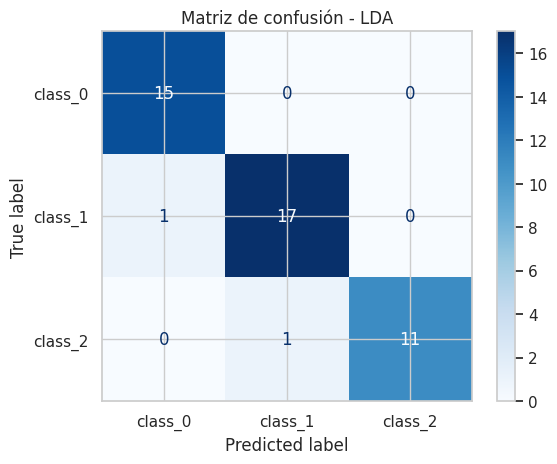

Interpretación:
La matriz de confusión permite observar en qué clases se producen errores.
Un buen modelo debe concentrar la mayor cantidad de valores en la diagonal principal.


In [21]:
# Entrenamiento final de LDA y evaluación en test
inicio = perf_counter()
lda.fit(X_train, y_train)
tiempo_lda = perf_counter() - inicio

y_pred_lda = lda.predict(X_test)

print(f"Tiempo de entrenamiento LDA: {tiempo_lda:.6f} segundos")
print("\nPrimeras 10 predicciones:")
print(y_pred_lda[:10])
print("Primeros 10 valores reales:")
print(y_test.to_numpy()[:10])

print("\nReporte de clasificación - LDA:")
print(classification_report(y_test, y_pred_lda, target_names=wine.target_names))

cm_lda = confusion_matrix(y_test, y_pred_lda)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_lda, display_labels=wine.target_names)
disp.plot(cmap="Blues")
plt.title("Matriz de confusión - LDA")
plt.show()

print("Interpretación:")
print("La matriz de confusión permite observar en qué clases se producen errores.")
print("Un buen modelo debe concentrar la mayor cantidad de valores en la diagonal principal.")

## 6. Implementación de QDA

In [22]:
# Modelo QDA
# reg_param=0.0 conserva la configuración sin regularización adicional.
qda = QuadraticDiscriminantAnalysis(
    priors=None,
    reg_param=0.0
)

print("Parámetros principales de QDA:")
print("- priors=None: las probabilidades a priori se estiman desde los datos de entrenamiento.")
print("- reg_param=0.0: no se aplica regularización de covarianza.")
print("- QDA permite una matriz de covarianza diferente para cada clase.")

Parámetros principales de QDA:
- priors=None: las probabilidades a priori se estiman desde los datos de entrenamiento.
- reg_param=0.0: no se aplica regularización de covarianza.
- QDA permite una matriz de covarianza diferente para cada clase.


In [23]:
# Validación cruzada de QDA en el conjunto de entrenamiento
scores_qda = cross_validate(
    qda,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

resumen_qda_cv = pd.DataFrame({
    "Métrica": scoring,
    "Media CV": [scores_qda[f"test_{m}"].mean() for m in scoring],
    "Desv. estándar CV": [scores_qda[f"test_{m}"].std() for m in scoring]
}).round(4)

display(resumen_qda_cv)

print("Interpretación:")
print("La validación cruzada muestra el desempeño promedio de QDA en varios pliegues estratificados.")
print("Esto es importante porque QDA es más flexible que LDA y puede variar más si hay pocas muestras por clase.")


,Métrica,Media CV,Desv. estándar CV
0,accuracy,0.9704,0.0277
1,precision_macro,0.9767,0.0212
2,recall_macro,0.9699,0.0306
3,f1_macro,0.9709,0.0287


Interpretación:
La validación cruzada muestra el desempeño promedio de QDA en varios pliegues estratificados.
Esto es importante porque QDA es más flexible que LDA y puede variar más si hay pocas muestras por clase.


Tiempo de entrenamiento QDA: 0.002226 segundos

Primeras 10 predicciones:
[0 1 0 0 1 0 0 1 1 2]
Primeros 10 valores reales:
[0 1 0 0 1 0 0 1 1 2]

Reporte de clasificación - QDA:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        15
     class_1       1.00      1.00      1.00        18
     class_2       1.00      1.00      1.00        12

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



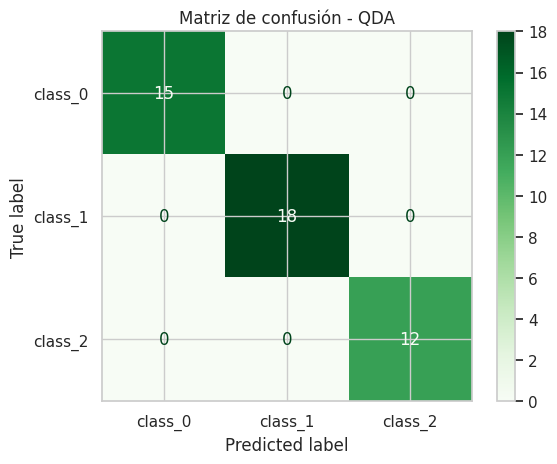

Interpretación:
QDA puede mejorar cuando las clases tienen formas de dispersión diferentes.
Sin embargo, su mayor flexibilidad debe analizarse junto con validación cruzada, no solo con un único test.


In [24]:
# Entrenamiento final de QDA y evaluación en test
inicio = perf_counter()
qda.fit(X_train, y_train)
tiempo_qda = perf_counter() - inicio

y_pred_qda = qda.predict(X_test)

print(f"Tiempo de entrenamiento QDA: {tiempo_qda:.6f} segundos")
print("\nPrimeras 10 predicciones:")
print(y_pred_qda[:10])
print("Primeros 10 valores reales:")
print(y_test.to_numpy()[:10])

print("\nReporte de clasificación - QDA:")
print(classification_report(y_test, y_pred_qda, target_names=wine.target_names))

cm_qda = confusion_matrix(y_test, y_pred_qda)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_qda, display_labels=wine.target_names)
disp.plot(cmap="Greens")
plt.title("Matriz de confusión - QDA")
plt.show()

print("Interpretación:")
print("QDA puede mejorar cuando las clases tienen formas de dispersión diferentes.")
print("Sin embargo, su mayor flexibilidad debe analizarse junto con validación cruzada, no solo con un único test.")


## 7. Comparación de modelos

In [25]:
# Función para calcular métricas finales en test
def calcular_metricas(y_real, y_pred):
    return {
        "Accuracy": accuracy_score(y_real, y_pred),
        "Precision macro": precision_score(y_real, y_pred, average="macro"),
        "Recall macro": recall_score(y_real, y_pred, average="macro"),
        "F1 macro": f1_score(y_real, y_pred, average="macro")
    }

metricas_test = pd.DataFrame([
    {"Modelo": "LDA", **calcular_metricas(y_test, y_pred_lda), "Tiempo entrenamiento (s)": tiempo_lda},
    {"Modelo": "QDA", **calcular_metricas(y_test, y_pred_qda), "Tiempo entrenamiento (s)": tiempo_qda}
])

# Métricas de validación cruzada
metricas_cv = pd.DataFrame([
    {
        "Modelo": "LDA",
        "Accuracy CV media": scores_lda["test_accuracy"].mean(),
        "F1 macro CV media": scores_lda["test_f1_macro"].mean(),
        "Accuracy CV std": scores_lda["test_accuracy"].std(),
        "F1 macro CV std": scores_lda["test_f1_macro"].std()
    },
    {
        "Modelo": "QDA",
        "Accuracy CV media": scores_qda["test_accuracy"].mean(),
        "F1 macro CV media": scores_qda["test_f1_macro"].mean(),
        "Accuracy CV std": scores_qda["test_accuracy"].std(),
        "F1 macro CV std": scores_qda["test_f1_macro"].std()
    }
])

comparacion_final = metricas_cv.merge(metricas_test, on="Modelo").round(4)
display(comparacion_final)

print("Interpretación:")
print("La comparación incluye validación cruzada y prueba final.")
print("Si un modelo gana en test pero pierde en CV, no conviene afirmar superioridad absoluta.")
print("En datasets pequeños, la validación cruzada da una visión más estable del comportamiento general.")


,Modelo,Accuracy CV media,F1 macro CV media,Accuracy CV std,F1 macro CV std,Accuracy,Precision macro,Recall macro,F1 macro,Tiempo entrenamiento (s)
0,LDA,0.9926,0.9924,0.0148,0.0152,0.9556,0.9606,0.9537,0.9562,0.0082
1,QDA,0.9704,0.9709,0.0277,0.0287,1.0000,1.0000,1.0000,1.0000,0.0022


Interpretación:
La comparación incluye validación cruzada y prueba final.
Si un modelo gana en test pero pierde en CV, no conviene afirmar superioridad absoluta.
En datasets pequeños, la validación cruzada da una visión más estable del comportamiento general.


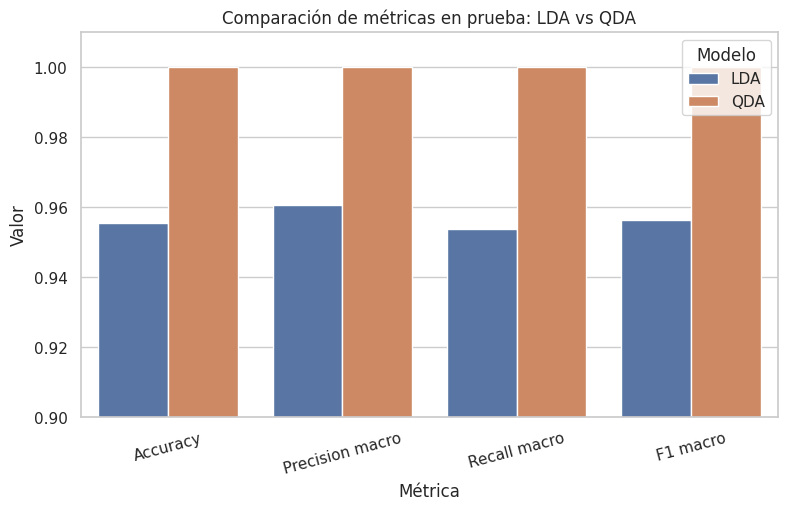

Interpretación:
El gráfico facilita comparar las métricas principales.
En clasificación multiclase se revisa F1 macro porque da peso similar a cada clase.


In [26]:
# Gráfico comparativo de métricas en test
metricas_plot = metricas_test.melt(
    id_vars="Modelo",
    value_vars=["Accuracy", "Precision macro", "Recall macro", "F1 macro"],
    var_name="Métrica",
    value_name="Valor"
)

plt.figure(figsize=(9, 5))
sns.barplot(data=metricas_plot, x="Métrica", y="Valor", hue="Modelo")
plt.ylim(0.90, 1.01)
plt.title("Comparación de métricas en prueba: LDA vs QDA")
plt.xticks(rotation=15)
plt.show()

print("Interpretación:")
print("El gráfico facilita comparar las métricas principales.")
print("En clasificación multiclase se revisa F1 macro porque da peso similar a cada clase.")

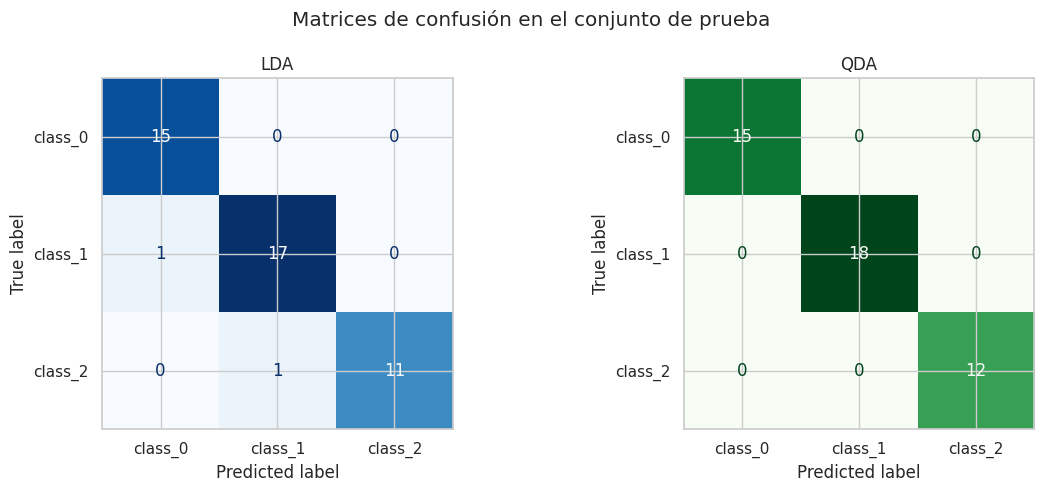

Interpretación:
LDA y QDA se comparan observando los errores por clase.
Cuando los errores aparecen fuera de la diagonal, indican confusiones entre cultivares.


In [27]:
# Comparación visual de matrices de confusión
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(cm_lda, display_labels=wine.target_names).plot(
    ax=axes[0], cmap="Blues", colorbar=False
)
axes[0].set_title("LDA")

ConfusionMatrixDisplay(cm_qda, display_labels=wine.target_names).plot(
    ax=axes[1], cmap="Greens", colorbar=False
)
axes[1].set_title("QDA")

plt.suptitle("Matrices de confusión en el conjunto de prueba")
plt.tight_layout()
plt.show()

print("Interpretación:")
print("LDA y QDA se comparan observando los errores por clase.")
print("Cuando los errores aparecen fuera de la diagonal, indican confusiones entre cultivares.")

## 8. Fronteras de decisión

In [28]:
# Para graficar fronteras se usan solo dos variables.
# Este modelo 2D es interpretativo, no reemplaza al modelo final con 13 variables.
var_x = "flavanoids"
var_y = "color_intensity"

X_2d = df[[var_x, var_y]]
y_2d = df["target"]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X_2d,
    y_2d,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_2d
)

lda_2d = LinearDiscriminantAnalysis(solver="svd")
qda_2d = QuadraticDiscriminantAnalysis(reg_param=0.0)

lda_2d.fit(X2_train, y2_train)
qda_2d.fit(X2_train, y2_train)

pred_lda_2d = lda_2d.predict(X2_test)
pred_qda_2d = qda_2d.predict(X2_test)

print("Desempeño usando solo dos variables:")
print(f"LDA 2D Accuracy: {accuracy_score(y2_test, pred_lda_2d):.4f}")
print(f"QDA 2D Accuracy: {accuracy_score(y2_test, pred_qda_2d):.4f}")


Desempeño usando solo dos variables:
LDA 2D Accuracy: 0.8667
QDA 2D Accuracy: 0.8889


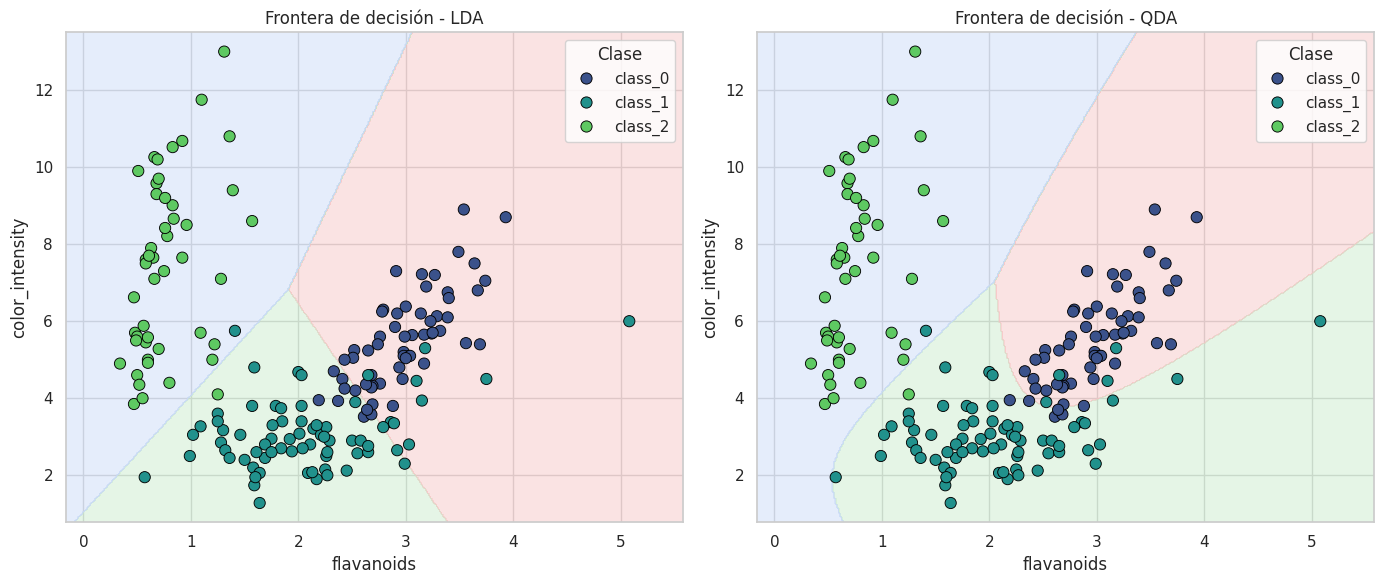

Analisis de las diferencias observadas
LDA produce regiones separadas por fronteras lineales.
QDA genera fronteras curvas porque estima una covarianza diferente para cada clase.
Con solo dos variables puede haber más solapamiento que usando las 13 variables originales.


In [31]:
# Función para graficar frontera de decisión
def graficar_frontera(modelo, X_data, y_data, ax, titulo):
    x_min, x_max = X_data.iloc[:, 0].min() - 0.5, X_data.iloc[:, 0].max() + 0.5
    y_min, y_max = X_data.iloc[:, 1].min() - 0.5, X_data.iloc[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 400),
        np.linspace(y_min, y_max, 400)
    )

    grid = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=[var_x, var_y])
    Z = modelo.predict(grid).reshape(xx.shape)

    cmap_fondo = ListedColormap(["#F6C1C1", "#C6EBC9", "#C7D8F7"])

    ax.contourf(xx, yy, Z, alpha=0.45, cmap=cmap_fondo)
    sns.scatterplot(
        x=X_data.iloc[:, 0],
        y=X_data.iloc[:, 1],
        hue=pd.Series(y_data).map(dict(enumerate(wine.target_names))),
        palette="viridis",
        edgecolor="black",
        s=65,
        ax=ax
    )
    ax.set_xlabel(var_x)
    ax.set_ylabel(var_y)
    ax.set_title(titulo)
    ax.legend(title="Clase", loc="best")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

graficar_frontera(lda_2d, X_2d, y_2d, axes[0], "Frontera de decisión - LDA")
graficar_frontera(qda_2d, X_2d, y_2d, axes[1], "Frontera de decisión - QDA")

plt.tight_layout()
plt.show()

print("Analisis de las diferencias observadas")
print("LDA produce regiones separadas por fronteras lineales.")
print("QDA genera fronteras curvas porque estima una covarianza diferente para cada clase.")
print("Con solo dos variables puede haber más solapamiento que usando las 13 variables originales.")

## 9. Conclusiones

1. **El Wine Dataset** es adecuado para comparar LDA y QDA porque es un problema de clasificación multiclase con variables predictoras numéricas.

2. **LDA** mostró un desempeño alto y estable porque varias variables químicas permiten separar correctamente las clases de vino.

3. **QDA** también obtuvo un buen desempeño, pero su mayor flexibilidad debe revisarse con validación cruzada para no depender solo de una partición entrenamiento/prueba.

4. La revisión de covarianzas ayuda a comprender los supuestos: **LDA usa una covarianza compartida**, mientras que **QDA permite una covarianza distinta por clase**.

5. La separación estratificada fue importante porque las clases no tienen exactamente la misma cantidad de observaciones y se necesitaba conservar esa proporción en entrenamiento y prueba.

6. Las matrices de confusión permiten ver no solo el porcentaje de aciertos, sino también qué clases se confunden entre sí.

7. Las fronteras de decisión muestran la diferencia principal entre los modelos: **LDA genera fronteras lineales** y **QDA puede generar fronteras curvas o cuadráticas**.

8. Como se trabajó sin tratamiento del dataset, los resultados reflejan el comportamiento directo de LDA y QDA sobre los datos originales.